# Week 5: Additional Models

### Goals:
- Try Decision Tree and Random Forest regressors
- Compare their test R^2 against baseline
- Document model behavior (strengths/weaknesses)

In [2]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from matplotlib.ticker import StrMethodFormatter
from sklearn.tree import DecisionTreeRegressor
import random
np.random.seed(42)
print("done")

done


In [3]:
# loading in data

filepath = r"C:\Users\julia\downloads\IDX_summer_internship"
train_df = pd.read_csv(filepath + r"\train_cleaned.csv", low_memory=False)
test_df = pd.read_csv(filepath + r"\test_cleaned.csv", low_memory=False)

print("HighSchoolDistrict" in train_df)
drop_cols = [
    "CloseDate", "ListPrice", "OriginalListPrice",
    "ListingKey", "ListingKeyNumeric", "DaysOnMarket", "HighSchoolDistrict"
]

x_train = train_df.drop(columns=["ClosePrice"] + drop_cols, errors="ignore")
x_test = test_df.drop(columns=["ClosePrice"] + drop_cols, errors="ignore")
y_train = train_df["ClosePrice"]
y_test = test_df["ClosePrice"]

print(f"X_train: {x_train.shape}")
print(f"X_test: {x_test.shape}")

True
X_train: (315683, 50)
X_test: (12634, 50)


In [4]:
# metrics function
def evaluate_model(y_true, y_pred, label="Model"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mdape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{label}")
    print(f"R²:    {r2:.4f}")
    print(f"RMSE:  ${rmse:,.0f}")
    print(f"MAE:   ${mae:,.0f}")
    print(f"MAPE:  {mape:.2f}%")
    print(f"MdAPE: {mdape:.2f}%")
    
    return {"Model": label, "R2": r2, "RMSE": rmse, 
            "MAE": mae, "MAPE": mape, "MdAPE": mdape}

In [6]:
# rerunning baseline linear regression for comparison
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
results_lr = evaluate_model(y_test, y_pred_lr, label="Linear Regression (Baseline)")
print(results_lr)


Linear Regression (Baseline)
R²:    0.4787
RMSE:  $653,574
MAE:   $436,431
MAPE:  43.73%
MdAPE: 30.42%
{'Model': 'Linear Regression (Baseline)', 'R2': 0.47871642694498506, 'RMSE': 653574.0200218135, 'MAE': 436430.8967468735, 'MAPE': 43.73403467791726, 'MdAPE': 30.417856170722413}


# Decision Tree
A decision tree learns to predict prices by working with feature values in a branching structure. Decision tree tends to overfit, as it grows without limits without manual limits, ex: max_depth. A max_depth of 10 is a reasonable middle ground for trainig which can be optimized later for hyperparameter training. 

NOTE: max_depth may be tuned in hyperparameter training

In [8]:
# decision tree
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
results_dt = evaluate_model(y_test, y_pred_dt, label="Decision Tree")

# check for overfitting - compare train vs test R²
print(f"\nDecision Tree Train R²: {r2_score(y_train, dt.predict(x_train)):.4f}")
print(f"Decision Tree Test R²:  {r2_score(y_test, y_pred_dt):.4f}")


Decision Tree
R²:    0.7814
RMSE:  $423,219
MAE:   $242,696
MAPE:  19.73%
MdAPE: 13.87%

Decision Tree Train R²: 0.8163
Decision Tree Test R²:  0.7814


# Random Forest 
A Random Forest is a large collection of decision trees that work together on a prediction, ex: 100 different trees and an average of their answers. As before, n_estimators is set to 100 as a starting value but can be tuned as a hyperparameter. Max_depth is set to 15 under this principle as well.

In [10]:
# random forest
# n_estimators = number of trees, can be tuned as a hyperparameter
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
results_rf = evaluate_model(y_test, y_pred_rf, label="Random Forest")

# check for overfitting
print(f"\nRandom Forest Train R²: {r2_score(y_train, rf.predict(x_train)):.4f}")
print(f"Random Forest Test R²:  {r2_score(y_test, y_pred_rf):.4f}")


Random Forest
R²:    0.8806
RMSE:  $312,748
MAE:   $167,504
MAPE:  13.20%
MdAPE: 8.95%

Random Forest Train R²: 0.9463
Random Forest Test R²:  0.8806


# Comparison Table of Linear Regression, Random Forest, and Decision Tree metrics

In [12]:
# side by side comparison
results_table = pd.DataFrame([results_lr, results_dt, results_rf])
results_table = results_table.set_index("Model")
results_table = results_table.round(4)
print(results_table)

                                  R2         RMSE          MAE     MAPE  \
Model                                                                     
Linear Regression (Baseline)  0.4787  653574.0200  436430.8967  43.7340   
Decision Tree                 0.7814  423218.6010  242696.4868  19.7290   
Random Forest                 0.8806  312747.7184  167503.9080  13.2004   

                                MdAPE  
Model                                  
Linear Regression (Baseline)  30.4179  
Decision Tree                 13.8696  
Random Forest                  8.9467  


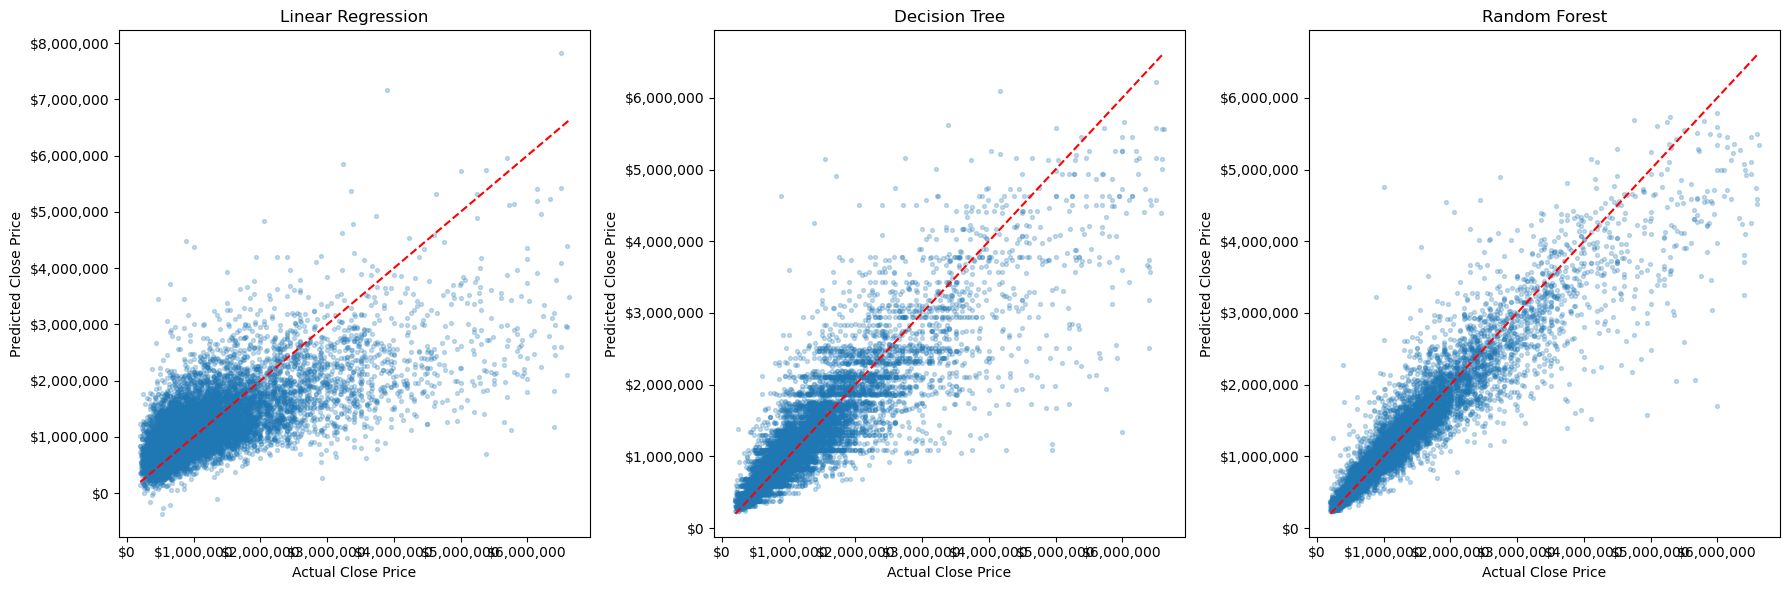

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = [
    ("Linear Regression", y_pred_lr),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf)
]

for ax, (name, preds) in zip(axes, models):
    ax.scatter(y_test, preds, alpha=0.25, s=8)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color="red", linestyle="--")
    ax.set_xlabel("Actual Close Price")
    ax.set_ylabel("Predicted Close Price")
    ax.set_title(name)
    ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
    ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.savefig(filepath + r"\model_comparison_plots.png", dpi=150, bbox_inches='tight')
plt.show()

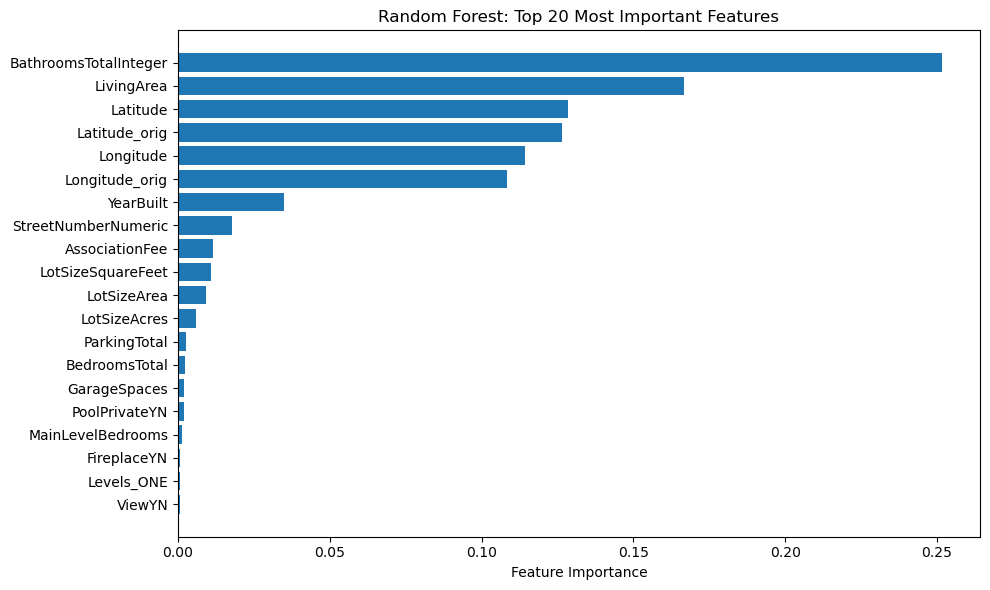

                  Feature  Importance
10  BathroomsTotalInteger    0.251548
4              LivingArea    0.166581
2                Latitude    0.128359
48          Latitude_orig    0.126352
3               Longitude    0.114296
49         Longitude_orig    0.108407
8               YearBuilt    0.035005
9     StreetNumberNumeric    0.017908
18         AssociationFee    0.011544
19      LotSizeSquareFeet    0.010818
14            LotSizeArea    0.009163
7            LotSizeAcres    0.005921
6            ParkingTotal    0.002660
11          BedroomsTotal    0.002215
17           GarageSpaces    0.002008
1           PoolPrivateYN    0.001914
15      MainLevelBedrooms    0.001310
12            FireplaceYN    0.000771
33             Levels_ONE    0.000765
0                  ViewYN    0.000506


In [14]:
# feature importance
importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Random Forest: Top 20 Most Important Features")
plt.tight_layout()
plt.show()

print(importance_df)

# Week 6 expanding on last week: Feature Enginnering
- Add geographic layer using school districts
- retrainig models with updated feature set
- New Features Added:
  - Bedroom to bathroom ratio
  - Property age in years at the time of sale
  - Living area per bedroom

In [16]:
# week 6 feature engineering

# new features on the test/train data

for df in [train_df, test_df]:
    # bed/bath ratio
    df["BedBathRatio"] = df["BedroomsTotal"] / (df["BathroomsTotalInteger"] + 1e-9)

    # property age at time of sale
    df['PropertyAge'] = 2026 - df['YearBuilt']

    #living area per bedroom
    df['AreaPerBedroom'] = df['LivingArea'] / (df['BedroomsTotal'] + 1e-9)

print("New Features Added: BedBathRatio, PropertyAge, AreaPerBedroom")

New Features Added: BedBathRatio, PropertyAge, AreaPerBedroom


In [17]:
# adding the school district spacial join, importing GeoPandas school district data
import geopandas as gpd
from shapely.geometry import Point

districts = gpd.read_file(r"C:\Users\julia\Downloads\IDX_summer_internship\ca_school_districts.geojson")
print(f"Districts loaded: {len(districts)}")
print(f"Columns: {districts.columns.tolist()}")
print(districts.head(2))

Districts loaded: 936
Columns: ['OBJECTID', 'Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictName', 'DistrictType', 'GradeLow', 'GradeHigh', 'GradeLowCensus', 'GradeHighCensus', 'AssistStatus', 'UpdateNotes', 'EnrollTotal', 'EnrollCharter', 'EnrollNonCharter', 'AAcount', 'AApct', 'AIcount', 'AIpct', 'AScount', 'ASpct', 'FIcount', 'FIpct', 'HIcount', 'HIpct', 'PIcount', 'PIpct', 'WHcount', 'WHpct', 'MRcount', 'MRpct', 'NRcount', 'NRpct', 'ELcount', 'ELpct', 'FOScount', 'FOSpct', 'HOMcount', 'HOMpct', 'MIGcount', 'MIGpct', 'SWDcount', 'SWDpct', 'SEDcount', 'SEDpct', 'DistrctAreaSqMi', 'LocaleCode', 'LocaleDesc', 'geometry']
   OBJECTID     Year    FedID   CDCode         CDSCode CountyName  \
0         1  2025-26  0601770  0161119  01611190000000    Alameda   
1         2  2025-26  0601860  0161127  01611270000000    Alameda   

          DistrictName DistrictType GradeLow GradeHigh  ... MIGcount MIGpct  \
0      Alameda Unified      Unified       PK        12  ...        0   

In [18]:
# filttering the school district dataset to only include "unified" (unified school districts only)

unified = districts[districts['DistrictType'] == 'Unified'].copy()
print(f"unified districtics: {len(unified)}")

unified districtics: 345


In [19]:
# converting each property's latitude and longitude into a geographic point

def add_school_district(df, districts_gdf):
    # convert lat/lon to geographic points -> creates a list of geographic Point objects, one per property
    geometry = [Point(lon, lat) for lon, lat in zip(df["Longitude_orig"], df["Latitude_orig"])]    # create geodataframe -> wraps pd df into a GeoPandas GeoDataFrame by attaching geometry column just created
    props_gdf = gpd.GeoDataFrame(df.copy(), geometry=geometry, crs="EPSG:4326") #EPSG is notation for standatd lat/lon degrees
    districts_gdf = districts_gdf.to_crs("EPSG:4326")

    # match CRS -> checks if school districut are in the same coordinate system, if not it converts it to match 
    if districts_gdf.crs != props_gdf.crs:
        districts_gdf = districts_gdf.to_crs("EPSG:4326")
    
    # spatial join -> for each property point finds which polygon it falls inside
    joined = gpd.sjoin(props_gdf,
                       districts_gdf[["DistrictName", "geometry"]],
                       how="left",
                       predicate="within")
    
    # drop geometry columns
    joined = joined.drop(columns=["geometry", "index_right"], errors="ignore")
    
    return pd.DataFrame(joined)
    
# run spatial join on train and test
print("Joining train data...")
train_df = add_school_district(train_df, unified)
print(f"Train done! Districts assigned: {train_df['DistrictName'].notna().sum():,}")

print("Joining test data...")
test_df = add_school_district(test_df, unified)
print(f"Test done! Districts assigned: {test_df['DistrictName'].notna().sum():,}")

Joining train data...
Train done! Districts assigned: 236,560
Joining test data...
Test done! Districts assigned: 9,509


In [20]:
# label encoding district
from sklearn.preprocessing import LabelEncoder

# fill missing districts with Unknown
train_df["DistrictName"] = train_df["DistrictName"].fillna("Unknown")
test_df["DistrictName"] = test_df["DistrictName"].fillna("Unknown")

# fit on training data - Unknown is in training so encoder learns it
le = LabelEncoder()
le.fit(train_df["DistrictName"])

train_df["DistrictEncoded"] = le.transform(train_df["DistrictName"])

# any test districts not seen in training get mapped to Unknown
test_df["DistrictName"] = test_df["DistrictName"].apply(
    lambda x: x if x in le.classes_ else "Unknown"
)
test_df["DistrictEncoded"] = le.transform(test_df["DistrictName"])

print(f"Unique districts encoded: {len(le.classes_)}")
print(f"Sample mapping:")
for name, code in zip(le.classes_[:5], range(5)):
    print(f"  {name} → {code}")

# save enriched datasets
train_df.to_csv(filepath + r"\train_enriched.csv", index=False)
test_df.to_csv(filepath + r"\test_enriched.csv", index=False)
print(f"train_enriched.csv saved — {len(train_df):,} rows")
print(f"test_enriched.csv saved — {len(test_df):,} rows")

Unique districts encoded: 324
Sample mapping:
  ABC Unified → 0
  Acton-Agua Dulce Unified → 1
  Alameda Unified → 2
  Albany City Unified → 3
  Alhambra Unified → 4
train_enriched.csv saved — 315,683 rows
test_enriched.csv saved — 12,634 rows


In [23]:
# rebuilding features with all new engineered columns
drop_cols_eng = [
    "CloseDate", "ListPrice", "OriginalListPrice",
    "ListingKey", "ListingKeyNumeric", "DaysOnMarket",
    "HighSchoolDistrict", "DistrictName",
    "Latitude_orig", "Longitude_orig",
    "DistrictMedianPrice"
]

x_train_eng = train_df.drop(columns=["ClosePrice"] + drop_cols_eng, errors="ignore")
x_test_eng = test_df.drop(columns=["ClosePrice"] + drop_cols_eng, errors="ignore")
y_train = train_df["ClosePrice"]
y_test = test_df["ClosePrice"]

# drop any remaining object columns
obj_cols = x_train_eng.select_dtypes(include="object").columns.tolist()
if obj_cols:
    print(f"Dropping object columns: {obj_cols}")
    x_train_eng = x_train_eng.drop(columns=obj_cols)
    x_test_eng = x_test_eng.drop(columns=obj_cols)

print(f"X_train_eng: {x_train_eng.shape}")
print(f"X_test_eng: {x_test_eng.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train_eng: (315683, 52)
X_test_eng: (12634, 52)
y_train: (315683,)
y_test: (12634,)


In [25]:
# retraining fandom forest with new features
rf_eng = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_eng.fit(x_train_eng, y_train)
y_pred_rf_eng = rf_eng.predict(x_test_eng)
results_rf_eng = evaluate_model(y_test, y_pred_rf_eng, label="Random Forest (engineered features)")


Random Forest (engineered features)
R²:    0.8920
RMSE:  $297,504
MAE:   $154,714
MAPE:  11.98%
MdAPE: 7.95%


In [26]:
comparison = pd.DataFrame([results_lr, results_dt, results_rf, results_rf_eng])
comparison = comparison.set_index("Model")

# format columns nicely
comparison["R2"] = comparison["R2"].map("{:.4f}".format)
comparison["RMSE"] = comparison["RMSE"].map("${:,.0f}".format)
comparison["MAE"] = comparison["MAE"].map("${:,.0f}".format)
comparison["MAPE"] = comparison["MAPE"].map("{:.2f}%".format)
comparison["MdAPE"] = comparison["MdAPE"].map("{:.2f}%".format)

# rename columns
comparison.columns = ["R²", "RMSE", "MAE", "MAPE", "MdAPE"]

comparison.style.set_properties(**{
    'text-align': 'center',
    'font-size': '12pt',
}).set_table_styles([{
    'selector': 'th',
    'props': [('text-align', 'center'),
              ('font-size', '12pt'),
              ('font-weight', 'bold')]
}])

,R²,RMSE,MAE,MAPE,MdAPE
Model,,,,,
Linear Regression (Baseline),0.4787,"$653,574","$436,431",43.73%,30.42%
Decision Tree,0.7814,"$423,219","$242,696",19.73%,13.87%
Random Forest,0.8806,"$312,748","$167,504",13.20%,8.95%
Random Forest (engineered features),0.8920,"$297,504","$154,714",11.98%,7.95%


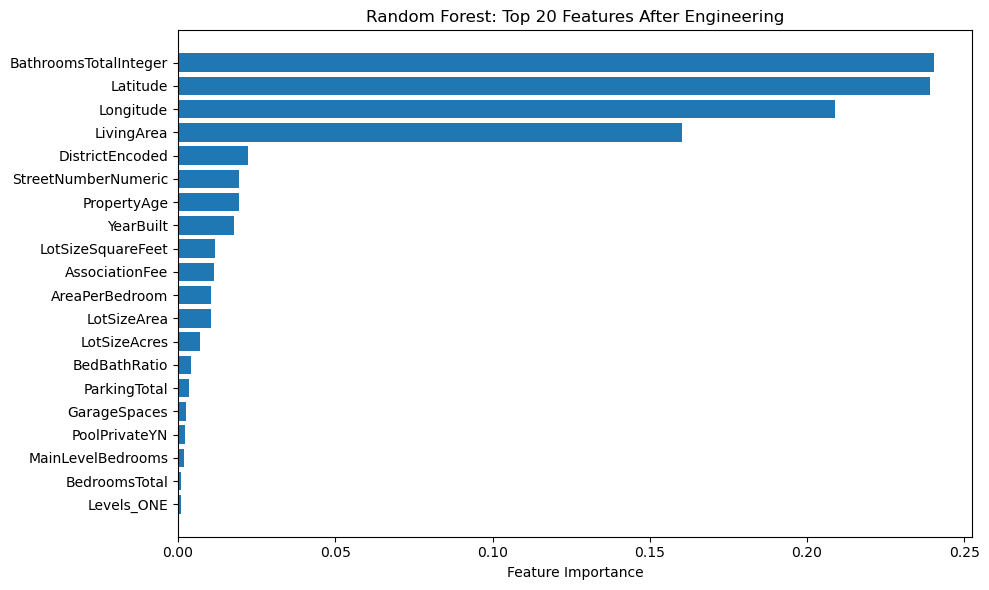

                  Feature  Importance
10  BathroomsTotalInteger    0.240499
2                Latitude    0.239001
3               Longitude    0.208754
4              LivingArea    0.160388
51        DistrictEncoded    0.022421
9     StreetNumberNumeric    0.019494
49            PropertyAge    0.019343
8               YearBuilt    0.017940
19      LotSizeSquareFeet    0.011703
18         AssociationFee    0.011390
50         AreaPerBedroom    0.010646
14            LotSizeArea    0.010630
7            LotSizeAcres    0.007033
48           BedBathRatio    0.004212
6            ParkingTotal    0.003644
17           GarageSpaces    0.002476
1           PoolPrivateYN    0.002148
15      MainLevelBedrooms    0.001782
11          BedroomsTotal    0.001096
33             Levels_ONE    0.000953


In [27]:
# feature importance with new features
importance_df = pd.DataFrame({
    "Feature": x_train_eng.columns,
    "Importance": rf_eng.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Random Forest: Top 20 Features After Engineering")
plt.tight_layout()
plt.show()

print(importance_df)

In [ ]:
# simple manual hyperparameter tuning

param_combos = [
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 100, "max_depth": 15},
    {"n_estimators": 100, "max_depth": 20},
    {"n_estimators": 200, "max_depth": 15},
]

tuning_results = []

for params in param_combos:
    print(f"Trying n_estimators={params['n_estimators']}, max_depth={params['max_depth']}...")
    
    rf_tune = RandomForestRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        random_state=42,
        n_jobs=-1
    )
    rf_tune.fit(x_train_eng, y_train)
    y_pred_tune = rf_tune.predict(x_test_eng)
    
    r2 = r2_score(y_test, y_pred_tune)
    mdape = np.median(np.abs((y_test - y_pred_tune) / y_test)) * 100
    
    print(f"  R²: {r2:.4f} | MdAPE: {mdape:.2f}%")
    tuning_results.append({**params, "R2": r2, "MdAPE": mdape})

# show results
tuning_df = pd.DataFrame(tuning_results)
print("\n--- Tuning Results ---")
print(tuning_df.sort_values("R2", ascending=False))

Trying n_estimators=100, max_depth=10...
  R²: 0.7963 | MdAPE: 13.22%
Trying n_estimators=100, max_depth=15...
  R²: 0.8720 | MdAPE: 9.15%
Trying n_estimators=100, max_depth=20...
